In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json
import torch

In [2]:
# for each item in the dict, if any two have the same 'record', 
# keep the one that has the lowest train_time
def deduplicate_metrics(search_results):
    # records_length_so_far = {}
    # new_search_results = {}
    # for key, value in search_results.items():
    #     if value['record'] not in records_length_so_far:
    #         records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
    #         new_search_results[key] = value
    #     else:
    #         if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
    #             new_search_results.pop(records_length_so_far[value['record']][1])

    #             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
    #             new_search_results[key] = value
    # return new_search_results
    records_train_time_so_far = {}
    new_search_results = {}
    for key, value in search_results.items():
        # get the min value where the train_time is not smaller than 40% of the train_time at 0
        base_train_time = value['metrics']['train_time'].tolist()[0]
        train_time_array = value['metrics']['train_time'].to_numpy()
        train_time = train_time_array[train_time_array >= 0.4 * base_train_time].min()
        # train_time = value['metrics']['train_time'].min()
        if value['record'] not in records_train_time_so_far:
            # get the min train time
            records_train_time_so_far[value['record']] = (train_time, key)
            new_search_results[key] = value
        else:
            if train_time < records_train_time_so_far[value['record']][0]:
                new_search_results.pop(records_train_time_so_far[value['record']][1])

                records_train_time_so_far[value['record']] = (train_time, key)
                new_search_results[key] = value
    return new_search_results



In [3]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
#         #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
#     ]
# )

In [4]:
# with open('may5.cache', 'w') as f:
#     json.dump(ori_results, f)
with open('/home/zhaobc/scientist/plot/may13.cache', 'r') as f:
    ori_results = json.load(f)

In [5]:
folder_info = ori_results
len(folder_info)

3591

In [6]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 50),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]
# for each search algo, we get the R1 and O3 with level 1, 12, 125 results for plotting
# thats 6 results for each search algo, so we plot with 3 columns (level) and 2 rows (R1 and O3)

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in [1, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            # print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info

In [22]:
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125]:
        for model in ('deepseek-r1', 'o3-mini'):
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
                figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict(plot_info[search_algo][level][model])
            except FileNotFoundError as e:
                print(f"File not found while processing metrics for {search_algo}, level {level}, model {model}: {e}")
            

In [23]:
len(plot_info['flat'][12]['deepseek-r1'].keys())

15

In [24]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}

human_train_time_variance = {
    1: 20183.68,
    2: 18300.36,
    3: 22270.99,
    4: 37980.47,
    5: 7365.53,
    6: 5922.16,
    7: 3805.14,
    8: 9496.43,
    9: 15747.18,
    10: 2315.29,
    11: 3259.97,
    12: 1220.16,
    13: 927.61,
    14: 6034.27,
    15: 2337.85,
    16: 6700.25,
    17: 40.5,
    18: 1495.18,
    19: 600.67,
    20: 770.64,
    21: 593.64,
}

In [25]:
for key in figure_data.keys():
    figure_data[key] = compute_gap_in_percentage(figure_data[key], human_train_time_dict)
    figure_data[key] = {str(k): v for k, v in figure_data[key].items()}
    del figure_data[key]['6']\

# replace the ones with 300% improvement with 0 as they might be summarizer mistakes
for key in figure_data.keys():
    for k, v in figure_data[key].items():
        if v > 3 or v < 0:
            # print(f'found {v} in {key} {k}')
            figure_data[key][k] = 0.


In [26]:
from parse_levels import workspace_base_path

In [27]:
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125]:
        for model in ('deepseek-r1', 'o3-mini'):
            for key in plot_info[search_algo][level][model].keys():
                folder_path = workspace_base_path(key)
                new_keys = {
                    'code_length': [],
                    'is_valid': [],
                    'debug_depth': [],
                    'train_time': [],
                }
                
                # take the first 20 versions
                for v in range(0, 21):

                    # get code length for each version
                    try:
                        code_file = os.path.join(folder_path, f'v_{v}', 'train_gpt2.py')
                        with open(code_file, 'r') as f:
                            code = f.readlines()
                        new_keys['code_length'].append(len(code))
                    except: 
                        new_keys['code_length'].append(0)

                    # get is_valid for each version
                    results_file = os.path.join(folder_path, f'v_{v}', 'results.json')
                    try:
                        with open(results_file, 'r') as f:
                            results = json.load(f)
                        try:
                            new_keys['is_valid'].append(results['metrics']['is_valid'])
                        except KeyError:
                            new_keys['is_valid'].append(True)
                    except:
                        new_keys['is_valid'].append(False)

                    try:
                        with open(results_file, 'r') as f:
                            results = json.load(f)
                        try:
                            new_keys['train_time'].append(results['metrics']['train_time'])
                        except KeyError:
                            new_keys['train_time'].append(-1)
                    except:
                        new_keys['train_time'].append(-1)

                    # get debug_depth for each version
                    debug_depth_file = os.path.join(folder_path, f'v_{v}', 'meta.json')
                    try:
                        with open(debug_depth_file, 'r') as f:
                            debug_depth = json.load(f)
                        try:
                            new_keys['debug_depth'].append(debug_depth['bug_depth'])
                        except KeyError:
                            new_keys['debug_depth'].append(0)
                    except:
                        new_keys['debug_depth'].append(-1)
                
                # metrics = plot_info[search_algo][level][model][key]['metrics']
                # metrics = pd.DataFrame(new_keys).join(metrics)
                metrics = pd.DataFrame(new_keys)
                plot_info[search_algo][level][model][key]['metrics'] = metrics

In [28]:
# plot buggy percentage
buggy_percentage = {}
for search_algo in search_algo_params.keys():
    buggy_percentage[search_algo] = {}
    for level in [1, 12, 125]:
        buggy_percentage[search_algo][level] = {}
        for model in ('deepseek-r1', 'o3-mini'):
            buggy_percentage[search_algo][level][model] = {}
            for key, value in plot_info[search_algo][level][model].items():
                non_buggy_count = sum(value['metrics']['is_valid'])
                buggy_percentage[search_algo][level][model][value['record']] = \
                    1 - non_buggy_count / len(value['metrics']['is_valid'])

In [29]:
# colors = ['crimson', 'royalblue', 'forestgreen', 'darkorange', 'purple', 'pink']
# for search_algo in ['flat', 'tree', 'forest', 'aide', 'multi_aide']:
#     filtered_figure_data = {k: v for k, v in buggy_percentage.items() if search_algo in k}
#     data_dicts = []
#     i = 0
#     for model in ('deepseek-r1', 'o3-mini'):
#         for level in [1, 12, 125]:
#             if level == 125:
#                 level_plot = 123
#             else:
#                 level_plot = level
#             data_dicts.append((
#                 buggy_percentage[search_algo][level][model], 
#                 f'hints: {level_plot} model: {model}', 
#                 colors[i]
#             ))
#             i += 1
#     plot_gap_comparison(
#         data_dicts, 
#         figsize=(15, 10), 
#         # n_cols=3, 
#         main_title=f'Buggy Percentage: {search_algo}'
#     )
#     # plt.savefig(f'../figures/{search_algo}_placeholder.pdf', dpi=150)
#     plt.show()

In [30]:
# plot faulty percentage
buggy_percentage_2 = {}
for search_algo in search_algo_params.keys():
    buggy_percentage_2[search_algo] = {}
    for level in [1, 12, 125]:
        buggy_percentage_2[search_algo][level] = {}
        for model in ('deepseek-r1', 'o3-mini'):
            buggy_percentage_2[search_algo][level][model] = {}
            for key, value in plot_info[search_algo][level][model].items():
                # print(value['metrics']['debug_depth'])
                # print(sum(value['metrics']['debug_depth'] > 0))
                buggy_count = sum(value['metrics']['debug_depth'] > 0)
                buggy_percentage_2[search_algo][level][model][value['record']] = \
                    buggy_count / len(value['metrics']['debug_depth'])

In [33]:
no_improvement = {}
for search_algo in search_algo_params.keys():
    no_improvement[search_algo] = {}
    for level in [1, 12, 125]:
        no_improvement[search_algo][level] = {}
        for model in ('deepseek-r1', 'o3-mini'):
            no_improvement[search_algo][level][model] = {}
            for key, value in plot_info[search_algo][level][model].items():
                record_id = value['record']
                human_time = human_train_time_dict[record_id]
                variance = human_train_time_variance[record_id]

                agent_times = value['metrics']['train_time'][value['metrics']['is_valid']].to_numpy()[1:]
                no_improvement[search_algo][level][model][record_id] = sum(agent_times > (human_time + variance)) / len(value['metrics']['is_valid'])


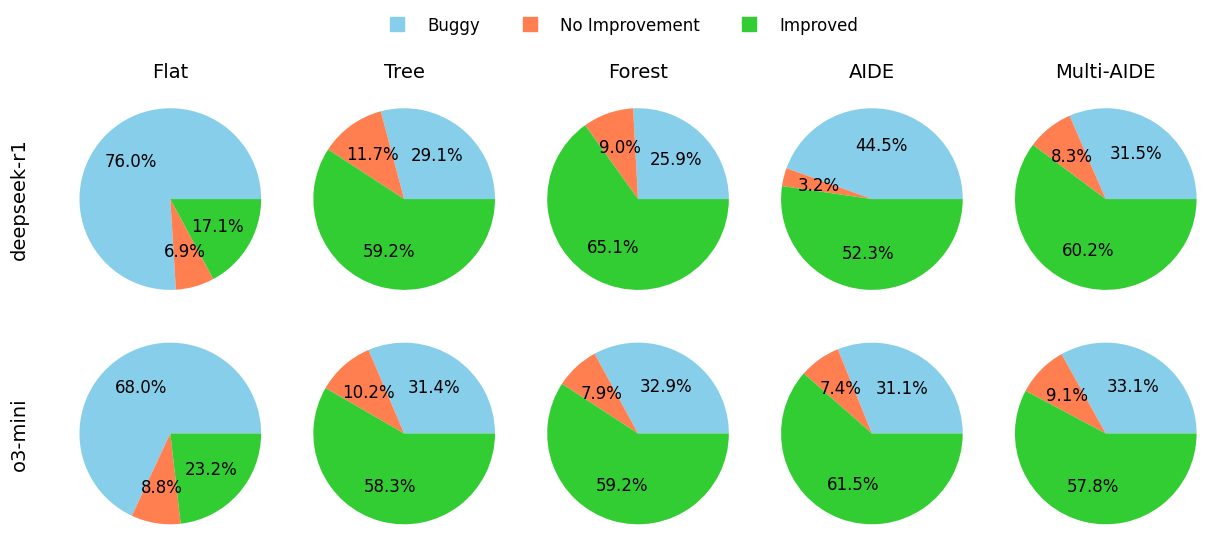

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
models = ['deepseek-r1', 'o3-mini']
search_algos = ['flat', 'tree', 'forest', 'aide', 'multi_aide']
# colors = ['#ff9999', '#ff9933', '#66b3ff']  # buggy, no improvement, good
colors = ['skyblue', 'coral', 'limegreen']
labels = ['Buggy', 'No Improvement', 'Improved']
search_algos_map = {
    'flat': 'Flat',
    'tree': 'Tree',
    'forest': 'Forest',
    'aide': 'AIDE',
    'multi_aide': 'Multi-AIDE'
}

for row, model in enumerate(models):
    for col, search_algo in enumerate(search_algos):
        # Calculate average percentages across all records and hint levels
        buggy_percentages = []
        no_improvement_percentages = []
        for level in [1, 12, 125]:
            buggy_values = list(buggy_percentage_2[search_algo][level][model].values())
            no_improvement_values = list(no_improvement[search_algo][level][model].values())
            buggy_percentages.extend(buggy_values)
            no_improvement_percentages.extend(no_improvement_values)
        
        avg_buggy = np.mean(buggy_percentages)
        avg_no_improvement = np.mean(no_improvement_percentages)
        avg_good = 1 - avg_buggy - avg_no_improvement
        
        # Create pie chart data
        sizes = [avg_buggy, avg_no_improvement, avg_good]  # [buggy, no improvement, good]
        
        # Plot pie chart without labels
        axes[row, col].pie(sizes, colors=colors, autopct='%1.1f%%', textprops={'fontsize': 12})
        if row == 0:
            axes[row, col].set_title(search_algos_map[search_algo], fontsize=14)
        if col == 0:
            axes[row, 0].set_ylabel(model, rotation=90, labelpad=20, fontsize=14)

label_patches = []
for i, lbl in enumerate(labels):
    label_patches.append(
        plt.Line2D([0], [0], marker='s', color=colors[i],
                   label=lbl, markersize=10, linestyle='None')
    )

fig.legend(label_patches, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
          ncol=3, frameon=False, fontsize=12)

plt.subplots_adjust(wspace=0.03, hspace=0.03)

for ax in axes.flat:
    ax.set(aspect='equal')  # ensure perfect circles
    ax.set_xticks([])       # remove ticks
    ax.set_yticks([])

plt.savefig(f'figures/buggy_percentage_pie_chart.pdf', dpi=200, bbox_inches='tight')
